<a href="https://colab.research.google.com/github/eppursimuove9/telcom_x/blob/main/TelcomX_Latam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Enlace RAW del dataset (API)
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

df = pd.read_json(url)
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#2. Exploración inicial y comprensión del dataset
En esta etapa se revisa la estructura del dataset, tipos de datos y se normaliza el JSON anidado para trabajar con columnas planas.

In [104]:
# Muestra la información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [105]:
# Muestra una muestra estadística rápida de las variables numéricas
df.describe()

,customerID,Churn,customer,phone,internet,account
count,7267,7267,7267,7267,7267,7267
unique,7267,3,891,3,129,6931
top,9995-HOTOH,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'No', 'OnlineSecurity': 'N...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
freq,1,5174,223,3495,1581,6


In [106]:
df_normalized = pd.json_normalize(df.to_dict(orient="records"))
df_normalized.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [107]:
df_normalized.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

Durante la exploración inicial se identificaron variables demográficas, contractuales y financieras. A partir del diccionario de datos provisto, se seleccionaron aquellas variables más relevantes para el análisis de evasión de clientes, priorizando información sobre contratos, antigüedad y cargos.

#3. Limpieza, tratamiento y verificación de incoherencias
Se revisan valores ausentes, duplicados, formatos y consistencia de categorías para asegurar que los datos estén listos para el análisis.

In [108]:
# Verificación básica de duplicados por customerID
dup_customer = df_normalized['customerID'].duplicated().sum()
dup_customer

np.int64(0)

In [109]:
# Limpieza de la variable objetivo: normalizo y filtro valores válidos (Yes/No)
df_normalized['Churn'] = df_normalized['Churn'].astype(str).str.strip()

df_normalized = df_normalized[df_normalized['Churn'].isin(['Yes', 'No'])].copy()

df_normalized['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [110]:
# TotalCharges llega como texto; se convierte a numérico para análisis cuantitativo
df_normalized['account.Charges.Total'] = pd.to_numeric(df_normalized['account.Charges.Total'], errors='coerce')

# Para tenure == 0, asumimos total gastado = 0 (sin historial de cobro acumulado)
mask_tenure0 = df_normalized['customer.tenure'] == 0
df_normalized.loc[mask_tenure0, 'account.Charges.Total'] = 0

# Revisión de nulos remanentes
df_normalized['account.Charges.Total'].isna().sum()

np.int64(0)

In [111]:
# Chequeo final: tipos consistentes y sin nulos en variables clave
df_normalized.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7043 non-null   object 
 1   Churn                      7043 non-null   object 
 2   customer.gender            7043 non-null   object 
 3   customer.SeniorCitizen     7043 non-null   int64  
 4   customer.Partner           7043 non-null   object 
 5   customer.Dependents        7043 non-null   object 
 6   customer.tenure            7043 non-null   int64  
 7   phone.PhoneService         7043 non-null   object 
 8   phone.MultipleLines        7043 non-null   object 
 9   internet.InternetService   7043 non-null   object 
 10  internet.OnlineSecurity    7043 non-null   object 
 11  internet.OnlineBackup      7043 non-null   object 
 12  internet.DeviceProtection  7043 non-null   object 
 13  internet.TechSupport       7043 non-null   object 
 1

Durante la preparación de los datos se verificó la ausencia de valores nulos relevantes, la inexistencia de registros duplicados por customerID y la consistencia de las categorías. Asimismo, se corrigieron errores de formato en variables numéricas y se validaron los valores de la variable objetivo (churn), asegurando que los datos estén listos para el análisis exploratorio.

#4. Feature engineering: creación de Cuentas_Diarias
Se crea la columna Cuentas_Diarias a partir de la facturación mensual (valor promedio diario).

In [112]:
df_normalized['Cuentas_Diarias'] = df_normalized['account.Charges.Monthly'] / 30

df_normalized[['account.Charges.Monthly', 'Cuentas_Diarias']].head()

,account.Charges.Monthly,Cuentas_Diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


Se creó la columna Cuentas_Diarias a partir de la facturación mensual, calculando un valor promedio diario. Esta variable permite analizar con mayor detalle el impacto de los cargos en el comportamiento de evasión de los clientes.

#5. Estandarización y transformación de datos (Extra - opcional)
De forma opcional, se realizan transformaciones adicionales para facilitar el análisis matemático y preparar el dataset para modelos predictivos.

In [113]:
# Conversión opcional de variables binarias a formato 0/1
df_normalized['Churn_bin'] = df_normalized['Churn'].map({'No': 0, 'Yes': 1})
df_normalized['PaperlessBilling_bin'] = df_normalized['account.PaperlessBilling'].map({'No': 0, 'Yes': 1})

df_normalized[['Churn','Churn_bin','account.PaperlessBilling','PaperlessBilling_bin']].head()

,Churn,Churn_bin,account.PaperlessBilling,PaperlessBilling_bin
0,No,0,Yes,1
1,No,0,No,0
2,Yes,1,Yes,1
3,Yes,1,Yes,1
4,Yes,1,Yes,1


Estas transformaciones permiten representar variables categóricas en un formato numérico, facilitando cálculos estadísticos y el desarrollo futuro de modelos predictivos. Al tratarse de un paso opcional, se implementó de forma controlada sin alterar los análisis exploratorios.

#6. Análisis Exploratorio de Datos (EDA)
A continuación se presentan análisis descriptivos y visualizaciones para identificar patrones asociados a la evasión.

##6.1 Análisis descriptivo de variables numéricas
Se calculan métricas descriptivas (media, mediana, desviación estándar, mínimos y máximos) para comprender la distribución de variables numéricas principales.

In [114]:
df_normalized[['customer.tenure','account.Charges.Monthly','account.Charges.Total','Cuentas_Diarias']].describe()

,customer.tenure,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304,2.158723
std,24.559481,30.090047,2266.794470,1.003002
min,0.000000,18.250000,0.000000,0.608333
25%,9.000000,35.500000,398.550000,1.183333
50%,29.000000,70.350000,1394.550000,2.345000
75%,55.000000,89.850000,3786.600000,2.995000
max,72.000000,118.750000,8684.800000,3.958333


##6.1 Distribución de evasión (Churn)
Se visualiza la proporción de clientes que permanecen vs. los que abandonan.

In [115]:
churn_pct = df_normalized['Churn'].value_counts(normalize=True) * 100
churn_pct

,proportion
Churn,
No,73.463013
Yes,26.536987


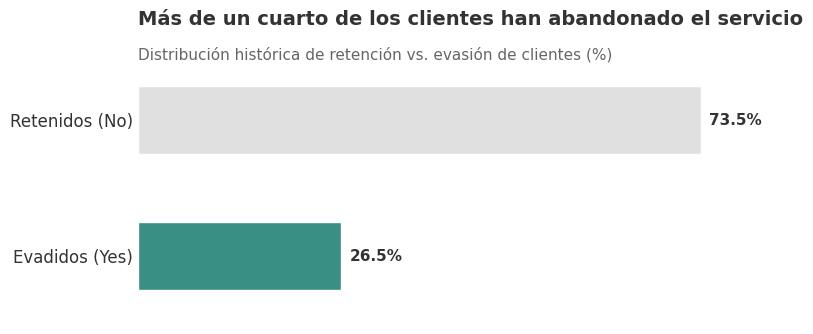

In [132]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1.Convertir la Serie a DataFrame
# Si churn_pct es una Serie, la transformamos a DataFrame
if isinstance(churn_pct, pd.Series):
    churn_pct = churn_pct.reset_index()
    # Aseguramos que las columnas tengan los nombres correctos para el gráfico
    churn_pct.columns = ['Churn', 'Porcentaje']

# 2. Limpiar el fondo completamente (sin cuadrículas)
sns.set_style("white")

# 3. Configurar el lienzo con proporciones elegantes
fig, ax = plt.subplots(figsize=(8, 3.5))

# 4. Colores estratégicos
colores_estrategicos = {'No': '#E0E0E0', 'Yes': '#2A9D8F'}

# 5. Crear el gráfico de barras
ax = sns.barplot(
    data=churn_pct,
    y='Churn',
    x='Porcentaje',
    orient='h',
    hue='Churn',
    palette=colores_estrategicos,
    legend=False,
    width=0.5
)

# 6. Títulos orientados a Insights (Action Titles)
plt.text(x=0, y=-0.7, s='Más de un cuarto de los clientes han abandonado el servicio',
         fontsize=14, fontweight='bold', color='#333333', ha='left')
plt.text(x=0, y=-0.45, s='Distribución histórica de retención vs. evasión de clientes (%)',
         fontsize=11, color='#666666', ha='left')

# 7. Eliminar todos los bordes (spines)
for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_visible(False)

# 8. Limpiar los ejes
ax.set_xticks([])
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='y', length=0, labelsize=12, colors='#333333')
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels(['Retenidos (No)', 'Evadidos (Yes)'])

# 9. Etiquetas de datos limpias y en negrita
for container in ax.containers:
    # Formateo a 1 decimal. Si tus datos no están multiplicados por 100 (ej. 0.26 en vez de 26),
    # puedes cambiar '%.1f%%' por '%.1f%%' o multiplicar tu columna Porcentaje antes.
    ax.bar_label(container, fmt='%.1f%%', padding=6, fontsize=11, fontweight='bold', color='#333333')

# Ajustar márgenes
plt.tight_layout()

# Guardar el gráfico en alta resolución (300 DPI)
plt.savefig('churn.png', dpi=300, bbox_inches='tight', facecolor='white', transparent=False)

plt.show()

##6.2 Recuento de evasión por variables categóricas
Se analiza churn según variables categóricas para identificar perfiles con mayor tendencia a abandono.

###6.2.1 Churn según tipo de contrato

In [117]:
churn_by_contract = (
    df_normalized
    .groupby('account.Contract')['Churn']
    .value_counts(normalize=True)
    .mul(100)
    .rename('percentage')
    .reset_index()
)
churn_by_contract

,account.Contract,Churn,percentage
0,Month-to-month,No,57.290323
1,Month-to-month,Yes,42.709677
2,One year,No,88.730482
3,One year,Yes,11.269518
4,Two year,No,97.168142
5,Two year,Yes,2.831858


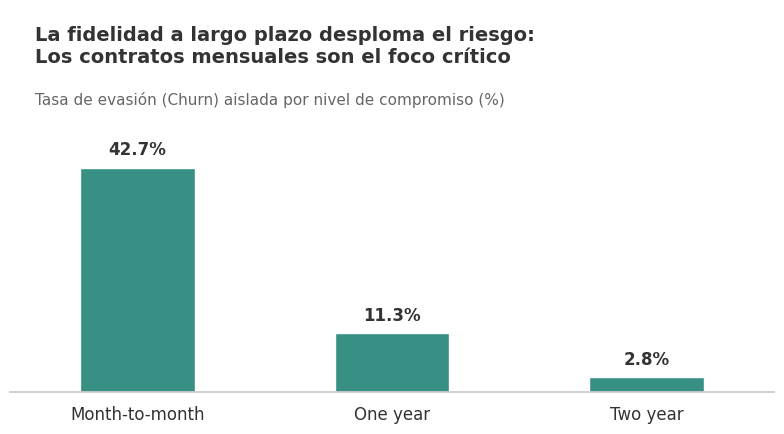

In [133]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. PREPARACIÓN ESTRATÉGICA
# Filtramos para aislar solo el problema (Churn == 'Yes')
df_churn_contract = churn_by_contract[churn_by_contract['Churn'] == 'Yes']

order_contract = ['Month-to-month', 'One year', 'Two year']

# 2. Estilo base limpio
sns.set_style("white")

# 3. Configurar el lienzo (más compacto al tener menos barras)
fig, ax = plt.subplots(figsize=(8, 4.5))

# 4. Crear el gráfico simple usando solo tu color de alerta corporativo
ax = sns.barplot(
    data=df_churn_contract,
    x='account.Contract',
    y='percentage',
    order=order_contract,
    color='#2A9D8F',
    width=0.45
)

# 5. Títulos orientados a Insights (Action Titles)
# Calculamos un techo dinámico para que los títulos siempre tengan espacio
techo_y = df_churn_contract['percentage'].max()
plt.ylim(0, techo_y + 30)

plt.text(x=-0.4, y=techo_y + 20, s='La fidelidad a largo plazo desploma el riesgo: \nLos contratos mensuales son el foco crítico',
         fontsize=14, fontweight='bold', color='#333333', ha='left')
plt.text(x=-0.4, y=techo_y + 12, s='Tasa de evasión (Churn) aislada por nivel de compromiso (%)',
         fontsize=11, color='#666666', ha='left')

# 6. Limpieza visual profunda
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#CCCCCC')

# Eliminamos ejes innecesarios
ax.set_ylabel('')
ax.set_xlabel('')
ax.set_yticks([])

# Limpiamos las etiquetas del eje X
ax.tick_params(axis='x', length=0, labelsize=12, colors='#333333', pad=10)

# 7. Etiquetas de datos exactas sobre cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=6, fontsize=12, fontweight='bold', color='#333333')

plt.tight_layout()

# Guardar el gráfico en alta resolución (300 DPI)
plt.savefig('churn_tipo_de_contrato.png', dpi=300, bbox_inches='tight', facecolor='white', transparent=False)

plt.show()

Se observa una relación clara entre el tipo de contrato y la evasión de clientes. Los clientes con contratos mensuales presentan la mayor tasa de churn, mientras que aquellos con contratos de uno y dos años muestran una probabilidad significativamente menor de abandono. Esto sugiere que los contratos de mayor duración contribuyen de forma efectiva a la retención de clientes.

###6.2.2 Churn según género

In [119]:
churn_by_gender = (
    df_normalized
    .groupby('customer.gender')['Churn']
    .value_counts(normalize=True)
    .mul(100)
    .rename('percentage')
    .reset_index()
)
churn_by_gender

,customer.gender,Churn,percentage
0,Female,No,73.079128
1,Female,Yes,26.920872
2,Male,No,73.839662
3,Male,Yes,26.160338


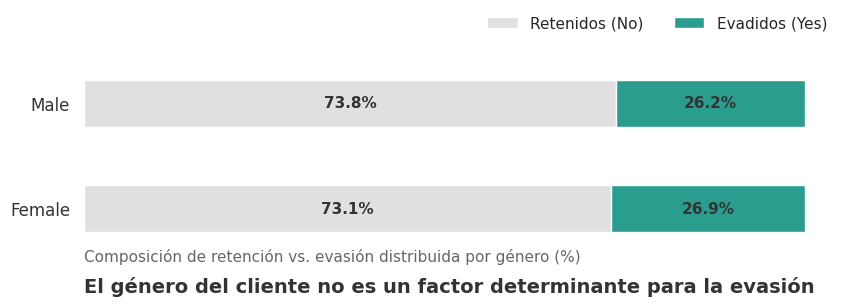

In [134]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Aseguramos el orden del pivot (Retenidos primero, para que el gris quede a la izquierda)
pivot_gender = pivot_gender[['No', 'Yes']]

# 2. Estilo base limpio
sns.set_style("white")

# 3. Lienzo más compacto (los gráficos apilados horizontales son muy eficientes en espacio)
fig, ax = plt.subplots(figsize=(9, 3.5))
colores_estrategicos = ['#E0E0E0', '#2A9D8F']

# 4. Crear el gráfico de barras APILADAS (stacked=True) y HORIZONTALES (barh)
pivot_gender.plot(kind='barh', stacked=True, ax=ax, color=colores_estrategicos, width=0.45)

# 5. Títulos orientados a Insights (Action Titles)
plt.text(x=0, y=-0.8, s='El género del cliente no es un factor determinante para la evasión',
         fontsize=14, fontweight='bold', color='#333333', ha='left')
plt.text(x=0, y=-0.5, s='Composición de retención vs. evasión distribuida por género (%)',
         fontsize=11, color='#666666', ha='left')

# 6. Limpieza visual profunda
for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_visible(False)

# Eliminamos ruido de los ejes
ax.set_ylabel('')
ax.set_xlabel('')
ax.set_xticks([])

# Limpiamos las etiquetas del eje Y (Female / Male)
ax.tick_params(axis='y', length=0, labelsize=12, colors='#333333', pad=10)

# 7. Etiquetas de datos EXACTAMENTE EN EL CENTRO de cada bloque
for container in ax.containers:
    # Si el valor es muy pequeño, podríamos ocultarlo, pero aquí caben perfecto
    ax.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=11, fontweight='bold', color='#333333')

# 8. Leyenda minimalista (arriba, en una sola línea horizontal)
plt.legend(labels=['Retenidos (No)', 'Evadidos (Yes)'], loc='upper right',
           frameon=False, fontsize=11, bbox_to_anchor=(1, 1.25), ncol=2)

plt.tight_layout()

# Guardar el gráfico en alta resolución (300 DPI)
plt.savefig('churn_por_genero.png', dpi=300, bbox_inches='tight', facecolor='white', transparent=False)

plt.show()

###6.2.3 Churn según método de pago

In [121]:
churn_by_payment = (
    df_normalized
    .groupby('account.PaymentMethod')['Churn']
    .value_counts(normalize=True)
    .mul(100)
    .rename('percentage')
    .reset_index()
)
churn_by_payment

,account.PaymentMethod,Churn,percentage
0,Bank transfer (automatic),No,83.290155
1,Bank transfer (automatic),Yes,16.709845
2,Credit card (automatic),No,84.756899
3,Credit card (automatic),Yes,15.243101
4,Electronic check,No,54.714588
5,Electronic check,Yes,45.285412
6,Mailed check,No,80.893300
7,Mailed check,Yes,19.106700


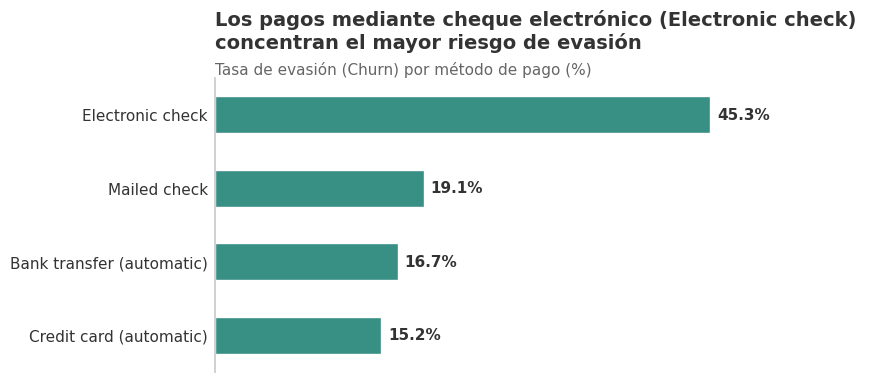

In [135]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. PREPARACIÓN ESTRATÉGICA DE DATOS
# Filtramos SOLO los clientes que se fueron y ordenamos de mayor a menor riesgo
df_churn_only = churn_by_payment[churn_by_payment['Churn'] == 'Yes'].sort_values(by='percentage', ascending=False)

# 2. Estilo base limpio
sns.set_style("white")

# 3. Configurar el lienzo (podemos hacerlo un poco menos alto al tener menos barras)
fig, ax = plt.subplots(figsize=(9, 4))

# 4. Crear el gráfico de barras horizontales simples
ax = sns.barplot(
    data=df_churn_only,
    y='account.PaymentMethod',
    x='percentage',
    color='#2A9D8F',
    width=0.5
)

# 5. Títulos orientados a Insights (Action Titles)
plt.text(x=0, y=-0.9, s='Los pagos mediante cheque electrónico (Electronic check)\nconcentran el mayor riesgo de evasión',
         fontsize=14, fontweight='bold', color='#333333', ha='left')
plt.text(x=0, y=-0.55, s='Tasa de evasión (Churn) por método de pago (%)',
         fontsize=11, color='#666666', ha='left')

# 6. Limpieza profunda de ejes y bordes
for spine in ['top', 'right', 'bottom']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')

# Eliminamos el eje X completo
ax.set_ylabel('')
ax.set_xlabel('')
ax.set_xticks([])

# Limpiamos las etiquetas del eje Y (las categorías de pago)
ax.tick_params(axis='y', length=0, labelsize=11, colors='#333333', pad=5)

# 7. Etiquetas de datos exactas al final de cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=5, fontsize=11, fontweight='bold', color='#333333')

# Damos espacio horizontal extra para que las etiquetas no se corten
plt.xlim(0, df_churn_only['percentage'].max() + 15)

plt.tight_layout()

# Guardar el gráfico en alta resolución (300 DPI)
plt.savefig('churn_metodo_de_pago.png', dpi=300, bbox_inches='tight', facecolor='white', transparent=False)

plt.show()

El análisis por variables categóricas permite observar diferencias en la evasión según el perfil y comportamiento de pago. En general, el tipo de contrato y el método de pago tienden a mostrar mayores diferencias en churn.

##6.3 Variables numéricas vs evasión
Se comparan distribuciones de variables numéricas entre clientes que cancelaron y los que no.

Para las variables numéricas (antigüedad, cargos mensuales y total gastado), se utilizaron boxplots, ya que permiten comparar de forma clara la distribución, mediana y presencia de valores atípicos entre clientes que evaden y los que no.

###6.3.1 Antigüedad (tenure) vs churn

In [123]:
df_normalized.groupby('Churn')['customer.tenure'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


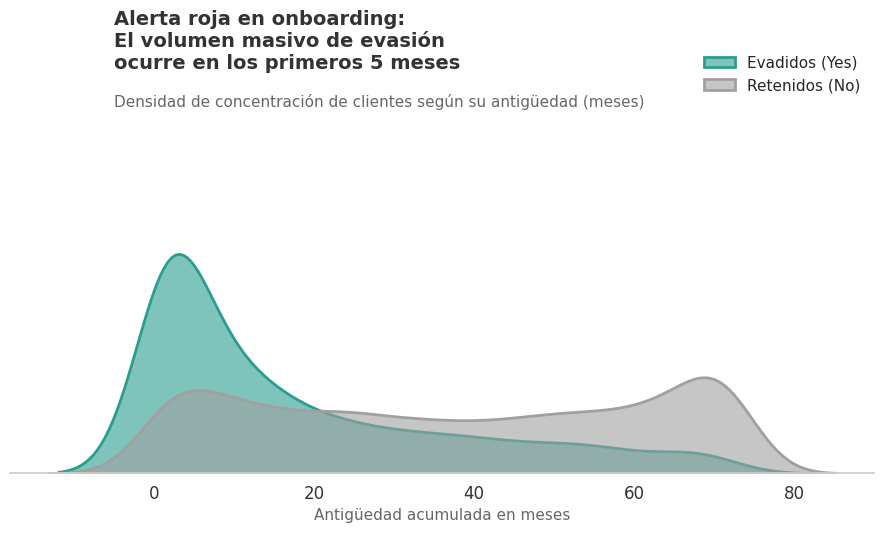

In [136]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Estilo base limpio
sns.set_style("white")

# 2. Configurar el lienzo (un poco más alargado)
fig, ax = plt.subplots(figsize=(9, 5.5))

# 3. Paleta estratégica (usamos un gris un poco más oscuro para que contraste con la transparencia)
colores_estrategicos = {'No': '#A0A0A0', 'Yes': '#2A9D8F'}

# 4. Crear el Gráfico de Densidad (KDE)
sns.kdeplot(
    data=df_normalized,
    x='customer.tenure',
    hue='Churn',
    fill=True,
    common_norm=False,
    palette=colores_estrategicos,
    alpha=0.6,
    linewidth=2,
    ax=ax
)

# 5. Damos "aire" en la parte superior para los títulos
plt.ylim(0, 0.08)

# 6. Títulos orientados a Insights (Action Titles)
plt.text(x=-5, y=0.075, s='Alerta roja en onboarding:\nEl volumen masivo de evasión\nocurre en los primeros 5 meses',
         fontsize=14, fontweight='bold', color='#333333', ha='left')
plt.text(x=-5, y=0.068, s='Densidad de concentración de clientes según su antigüedad (meses)',
         fontsize=11, color='#666666', ha='left')

# 7. Limpieza visual profunda
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#CCCCCC')

# Eliminamos el eje Y (en densidad importa la forma, no el número exacto)
ax.set_ylabel('')
ax.set_yticks([])

# Clarificamos el eje X
ax.set_xlabel('Antigüedad acumulada en meses', fontsize=11, color='#666666')
ax.tick_params(axis='x', length=0, labelsize=12, colors='#333333', pad=8)

# 8. Leyenda minimalista
plt.legend(labels=['Evadidos (Yes)', 'Retenidos (No)'], frameon=False, loc='upper right')

plt.tight_layout()

# Guardar el gráfico en alta resolución (300 DPI)
plt.savefig('antiguedad_y_churn.png', dpi=300, bbox_inches='tight', facecolor='white', transparent=False)

plt.show()

Los clientes que abandonan el servicio tienden a presentar menor antigüedad. Esto sugiere que el churn ocurre con mayor frecuencia en etapas tempranas de la relación con la empresa.

###6.3.2 Cargos mensuales vs churn

In [125]:
df_normalized.groupby('Churn')['account.Charges.Monthly'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


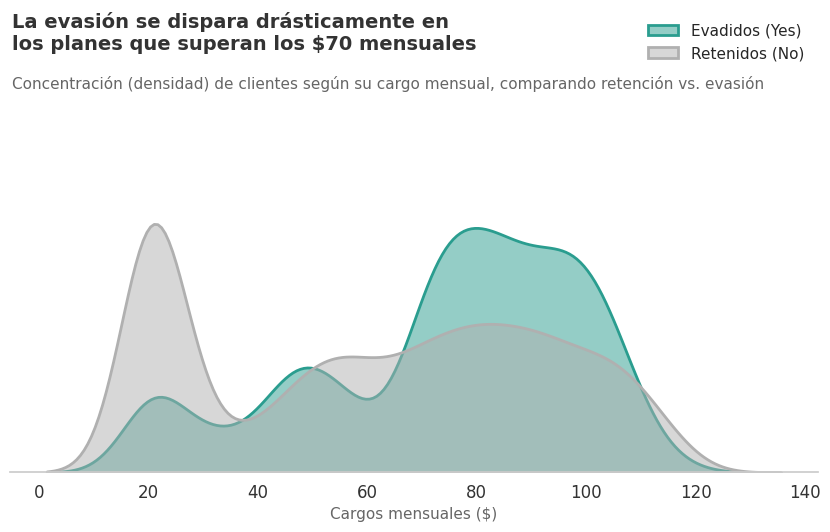

In [137]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Estilo base limpio
sns.set_style("white")

# 2. Configurar el lienzo (un poco más ancho para ver bien las curvas)
fig, ax = plt.subplots(figsize=(9, 5.5))

# 3. Paleta estratégica
colores_estrategicos = {'No': '#B0B0B0', 'Yes': '#2A9D8F'}

# 4. Crear el Gráfico de Densidad (KDE)
sns.kdeplot(
    data=df_normalized,
    x='account.Charges.Monthly',
    hue='Churn',
    fill=True,
    common_norm=False,
    palette=colores_estrategicos,
    alpha=0.5,
    linewidth=2,
    ax=ax
)

# 5. Damos "aire" en la parte superior para los títulos
plt.ylim(0, 0.035)

# 6. Títulos orientados a Insights (Action Titles)
plt.text(x=-5, y=0.032, s='La evasión se dispara drásticamente en\nlos planes que superan los $70 mensuales',
         fontsize=14, fontweight='bold', color='#333333', ha='left')
plt.text(x=-5, y=0.029, s='Concentración (densidad) de clientes según su cargo mensual, comparando retención vs. evasión',
         fontsize=11, color='#666666', ha='left')

# 7. Limpieza visual profunda
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#CCCCCC')

# Eliminamos el eje Y porque en densidad lo que importa es la forma, no el número exacto del eje Y
ax.set_ylabel('')
ax.set_yticks([])

# Clarificamos el eje X
ax.set_xlabel('Cargos mensuales ($)', fontsize=11, color='#666666')
ax.tick_params(axis='x', length=0, labelsize=12, colors='#333333', pad=8)

# 8. Leyenda minimalista
plt.legend(labels=['Evadidos (Yes)', 'Retenidos (No)'], frameon=False, loc='upper right')

plt.tight_layout()

# Guardar el gráfico en alta resolución (300 DPI)
plt.savefig('cargos_mensuales_y_churn.png', dpi=300, bbox_inches='tight', facecolor='white', transparent=False)

plt.show()

Los clientes que abandonan el servicio presentan, en promedio, cargos mensuales más elevados. Esto sugiere que el costo del servicio puede influir en la decisión de abandono.

###6.3.3 Total gastado vs churn

In [127]:
df_normalized.groupby('Churn')['account.Charges.Total'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,2549.911442,2329.954215,0.00,572.9,1679.525,4262.85,8672.45
Yes,1869.0,1531.796094,1890.822994,18.85,134.5,703.550,2331.30,8684.80


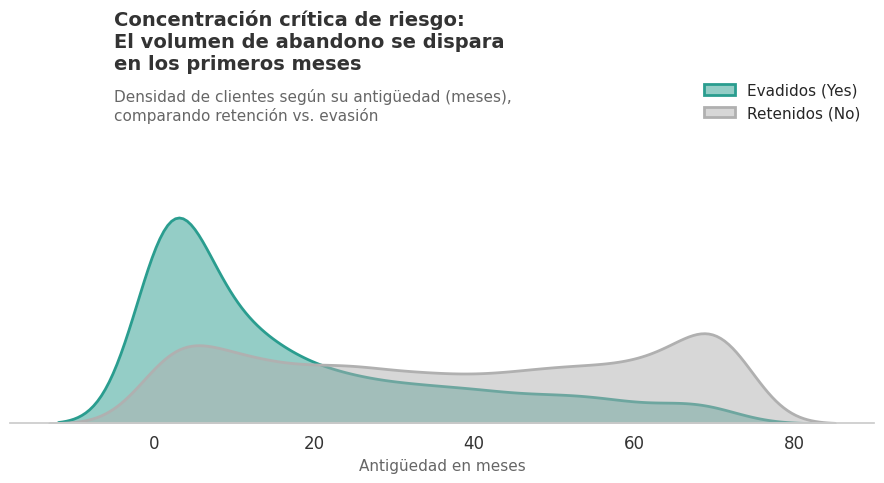

In [138]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("white")
fig, ax = plt.subplots(figsize=(9, 5))
colores_estrategicos = {'No': '#B0B0B0', 'Yes': '#2A9D8F'}

# Usamos kdeplot (Kernel Density Estimate)
sns.kdeplot(
    data=df_normalized,
    x='customer.tenure',
    hue='Churn',
    fill=True,
    common_norm=False,
    palette=colores_estrategicos,
    alpha=0.5,
    linewidth=2,
    ax=ax
)

plt.ylim(0, 0.07) # Ajustamos el techo para los títulos

plt.text(x=-5, y=0.070, s='Concentración crítica de riesgo:\nEl volumen de abandono se dispara\nen los primeros meses',
         fontsize=14, fontweight='bold', color='#333333', ha='left')
plt.text(x=-5, y=0.060, s='Densidad de clientes según su antigüedad (meses),\ncomparando retención vs. evasión',
         fontsize=11, color='#666666', ha='left')

# Limpieza
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#CCCCCC')

ax.set_ylabel('')
ax.set_xlabel('Antigüedad en meses', fontsize=11, color='#666666')
ax.set_yticks([])
ax.tick_params(axis='x', length=0, labelsize=12, colors='#333333', pad=8)

# Leyenda
plt.legend(labels=['Evadidos (Yes)', 'Retenidos (No)'], frameon=False, loc='upper right')

plt.tight_layout()

# Guardar el gráfico en alta resolución (300 DPI)
plt.savefig('total_gastado_y_churn.png', dpi=300, bbox_inches='tight', facecolor='white', transparent=False)

plt.show()

El total gastado suele estar asociado a la antigüedad: clientes con menor tenure tienden a acumular menor gasto total y concentran mayor evasión.

#7. Análisis de correlación entre variables (Extra - opcional)
Este análisis explora correlaciones entre variables numéricas y churn (binario). Las correlaciones no implican causalidad, pero pueden orientar modelos predictivos.

In [129]:
corr_vars = df_normalized[['Churn_bin','customer.tenure','account.Charges.Monthly','account.Charges.Total','Cuentas_Diarias']].copy()
corr_matrix = corr_vars.corr(numeric_only=True)
corr_matrix

,Churn_bin,customer.tenure,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
Churn_bin,1.000000,-0.352229,0.193356,-0.198324,0.193356
customer.tenure,-0.352229,1.000000,0.247900,0.826178,0.247900
account.Charges.Monthly,0.193356,0.247900,1.000000,0.651174,1.000000
account.Charges.Total,-0.198324,0.826178,0.651174,1.000000,0.651174
Cuentas_Diarias,0.193356,0.247900,1.000000,0.651174,1.000000


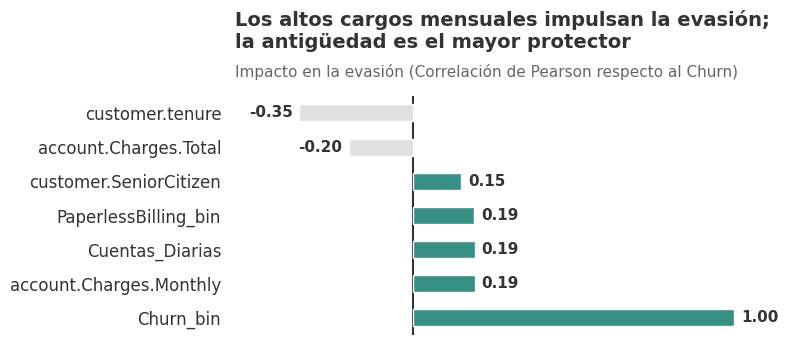

In [139]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. PREPARACIÓN ESTRATÉGICA
# (Asumiendo que df_temp ya tiene tu 'Churn_num' numérico calculado)
corr_matrix_num = df_temp.select_dtypes(include='number').corr()
impacto_churn = corr_matrix_num['Churn_num'].drop('Churn_num').sort_values()

# 2. Estilo base limpio
sns.set_style("white")
fig, ax = plt.subplots(figsize=(8, 4.5))

# Colores condicionales
colores_impacto = ['#E0E0E0' if val < 0 else '#2A9D8F' for val in impacto_churn.values]

# 3.
sns.barplot(
    x=impacto_churn.values,
    y=impacto_churn.index,
    hue=impacto_churn.index,
    legend=False,
    palette=colores_impacto,
    ax=ax,
    width=0.5
)

# 4. Títulos anclados perfectamente a la izquierda (transAxes)
ax.text(x=0, y=1.20, s='Los altos cargos mensuales impulsan la evasión;\nla antigüedad es el mayor protector',
         fontsize=14, fontweight='bold', color='#333333', ha='left',
         transform=ax.transAxes)

ax.text(x=0, y=1.08, s='Impacto en la evasión (Correlación de Pearson respecto al Churn)',
         fontsize=11, color='#666666', ha='left',
         transform=ax.transAxes)

# 5. Limpieza visual profunda
for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(False)

# Línea vertical sólida en el cero
ax.axvline(0, color='#333333', linewidth=1.5, zorder=0)

ax.set_ylabel('')
ax.set_xlabel('')
ax.set_xticks([])
ax.tick_params(axis='y', length=0, labelsize=12, colors='#333333', pad=10)

# 6. Etiquetas de datos exactas
for i, v in enumerate(impacto_churn.values):
    alineacion = 'right' if v < 0 else 'left'
    desplazamiento = -0.02 if v < 0 else 0.02

    ax.text(
        v + desplazamiento, i,
        f"{v:.2f}",
        color='#333333',
        fontweight='bold',
        fontsize=11,
        va='center',
        ha=alineacion
    )

plt.xlim(impacto_churn.min() - 0.2, impacto_churn.max() + 0.1)

# Ajustamos los márgenes del lienzo para que el título no se corte
plt.tight_layout(rect=[0, 0, 1, 0.85])

# Guardar el gráfico en alta resolución (300 DPI)
plt.savefig('correlacion_de_pearson.png', dpi=300, bbox_inches='tight', facecolor='white', transparent=False)

plt.show()

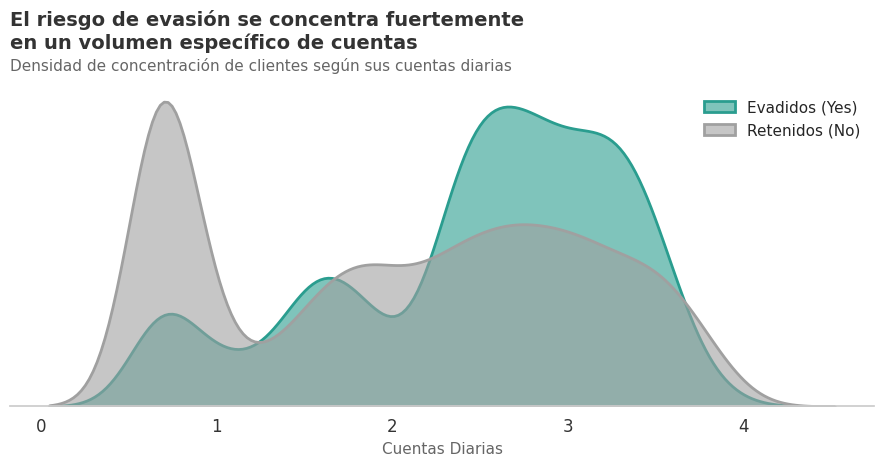

In [140]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Estilo base limpio
sns.set_style("white")

# 2. Configurar el lienzo (un poco más alargado para ver bien las curvas)
fig, ax = plt.subplots(figsize=(9, 5.5))

# 3. Paleta estratégica (gris un poco más oscuro para que contraste bien con la transparencia)
colores_estrategicos = {'No': '#A0A0A0', 'Yes': '#2A9D8F'}

# 4. Crear el Gráfico de Densidad (KDE)
sns.kdeplot(
    data=df_normalized,
    x='Cuentas_Diarias',
    hue='Churn',
    fill=True,              # Rellena el área bajo la curva para mostrar "volumen"
    common_norm=False,      # Calcula la densidad de cada grupo de forma independiente
    palette=colores_estrategicos,
    alpha=0.6,              # Transparencia elegante para ver dónde se cruzan las curvas
    linewidth=2,
    ax=ax
)

# 5. Títulos orientados a Insights anclados perfectamente a la izquierda (transAxes)
# NOTA: Ajusta el insight del título según lo que veas al ejecutar el gráfico.
ax.text(x=0, y=1.12, s='El riesgo de evasión se concentra fuertemente\nen un volumen específico de cuentas',
         fontsize=14, fontweight='bold', color='#333333', ha='left',
         transform=ax.transAxes)

ax.text(x=0, y=1.05, s='Densidad de concentración de clientes según sus cuentas diarias',
         fontsize=11, color='#666666', ha='left',
         transform=ax.transAxes)

# 6. Limpieza visual profunda
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#CCCCCC')

# Eliminamos el eje Y (en los gráficos de densidad importa la forma visual, no el número exacto del eje Y)
ax.set_ylabel('')
ax.set_yticks([])

# Clarificamos el eje X
ax.set_xlabel('Cuentas Diarias', fontsize=11, color='#666666')
ax.tick_params(axis='x', length=0, labelsize=12, colors='#333333', pad=8)

# 7. Leyenda minimalista
plt.legend(labels=['Evadidos (Yes)', 'Retenidos (No)'], frameon=False, loc='upper right')

# Ajustamos márgenes para no cortar los títulos que están por encima del gráfico
plt.tight_layout(rect=[0, 0, 1, 0.90])

# Guardar el gráfico en alta resolución (300 DPI)
plt.savefig('concentracion_clientes_segun_cuentas_diarias.png', dpi=300, bbox_inches='tight', facecolor='white', transparent=False)

plt.show()

El análisis de correlación suele mostrar una relación negativa entre churn y antigüedad (tenure), indicando que a mayor permanencia, menor probabilidad de evasión. También se observa relación positiva entre churn y cargos (mensuales/diarios), lo que refuerza los hallazgos del EDA. Estas relaciones son exploratorias y pueden ser útiles en el desarrollo futuro de modelos predictivos. Los cargos diarios se estiman asumiendo meses de 30 días como simplificación analítica.

#8. Cierre del proyecto: conclusiones, insights y recomendaciones

## 📌 Conclusiones Ejecutivas y Siguientes Pasos

---

### 1. Síntesis Ejecutiva

El modelo de retención actual presenta una vulnerabilidad estructural en las etapas tempranas del ciclo de vida del cliente. La fuga de capital no es uniforme, sino que está hiperconcentrada en un arquetipo específico: **clientes recientes, bajo contratos sin amarre (mensuales) y con altos cargos de facturación.** Para proteger los ingresos, la compañía debe transicionar urgentemente de una retención reactiva a un modelo de fidelización proactiva desde el día cero.

### 2. Diagnóstico de Negocio (Key Insights)

* **🚨 Crisis de retención en el Onboarding (Meses 0-5):** La antigüedad actúa como el principal escudo protector contra la evasión; sin embargo, el mayor volumen de abandonos ocurre durante los primeros meses. Se están perdiendo clientes antes de que logren consolidarse, destruyendo el *Lifetime Value* (LTV) proyectado.

* **🔓 Falta de Lock-in comercial:** El riesgo de evasión está acaparado casi en su totalidad por los contratos mensuales. La ausencia de un compromiso a largo plazo (contratos de 1 o 2 años) elimina las barreras de salida y facilita un abandono sin fricción para el cliente.

* **💸 Fractura en la propuesta de valor High-Ticket:** Existe una correlación directa y positiva entre el nivel de facturación (cargos diarios/mensuales) y la probabilidad de *churn*. Los clientes que más pagan son los que más rápido se van, lo que indica que el valor percibido del servicio actualmente no justifica el precio premium.

### 3. Plan de Acción Estratégico (Recomendaciones)

* **🎯 Forzar la migración al largo plazo (Upselling de Contratos):** Diseñar una estructura de *pricing* o incentivos agresivos de entrada (ej. descuentos significativos o beneficios extra) que hagan financieramente irracional elegir un contrato mensual frente a uno anual.

* **🛡️ Blindar los primeros 180 días:** Implementar un programa de *Customer Success* focalizado exclusivamente en clientes nuevos. El objetivo debe ser garantizar la adopción del servicio y mitigar la fricción durante el periodo crítico de mayor riesgo de fuga.

* **🔍 Auditar y reestructurar planes de alto costo:** Detener la hemorragia en el segmento de mayor facturación. Es imperativo revisar los beneficios asociados a las tarifas más altas para alinear el costo del servicio con un valor percibido superior.

* **🤖 Desplegar un motor predictivo de riesgo:** Utilizar esta "triada de vulnerabilidad" (Contrato, Antigüedad, Cargos) como base fundamental para entrenar un modelo de *Machine Learning* que identifique clientes con alta probabilidad de fuga *antes* de que soliciten la baja, permitiendo intervenciones comerciales preventivas.